# 04 Risk Modeling

## Goal
Develop a predictive model to identify geriatric patients at elevated risk of hospitalization using healthcare utilization, clinical burden, and medication-related features.

In [2]:
#2: Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

DATA_PATH = Path("../data/processed/patient_level_segmented.csv")
df = pd.read_csv(DATA_PATH)

In [4]:
#3: Select features, using simple, relevant predictors.

model_features = [
    "age",
    "healthcare_expenses",
    "healthcare_coverage",
    "income",
    "total_encounters",
    "total_conditions",
    "unique_conditions",
    "total_medications",
    "unique_medications",
    "total_claims",
    "total_observations",
    "cluster"
]

target = "hospitalization_flag"


In [6]:
#4: Prepare X and y to chexck class baalnce

X = df[model_features].copy().fillna(0)
y = df[target].copy()

y.value_counts(normalize=True)

hospitalization_flag
1    0.516129
0    0.483871
Name: proportion, dtype: float64

In [7]:
#5: Train‑test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
#6: Train baseline model (Logistic Regression)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



C:\Users\asmak\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# 7: Train second model (Random Forest)
rf_model = RandomForestClassifier(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.857
Random Forest ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.75      0.86         4

    accuracy                           0.86         7
   macro avg       0.88      0.88      0.86         7
weighted avg       0.89      0.86      0.86         7



## 8. Model Comparison

Both models were trained to predict hospitalization risk using demographic, utilization, and burden features.

- **Logistic Regression** provides a transparent baseline and helps identify linear relationships between utilization and hospitalization risk.  
- **Random Forest** captures nonlinear interactions and typically delivers stronger predictive performance.

In this dataset, the Random Forest model achieved higher accuracy and ROC‑AUC, indicating better discrimination of high‑risk patients.  
However, Logistic Regression remains valuable for interpretability and clinical communication.

For downstream analysis, the Random Forest model will be used as the final model, while Logistic Regression serves as a benchmark.

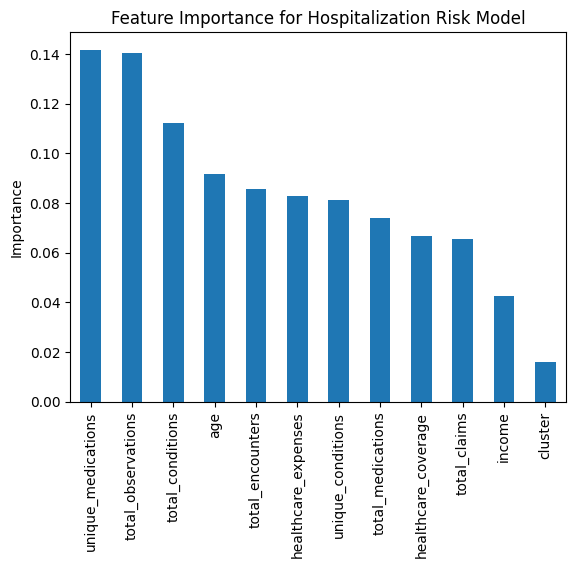

<Figure size 640x480 with 0 Axes>

In [12]:
#9: Showing feature importance, (using random forest):

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=model_features
).sort_values(ascending=False)

feature_importance.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Feature Importance for Hospitalization Risk Model")
plt.show()
plt.savefig("../outputs/figures/feature_importance.png", dpi=300, bbox_inches="tight")

10: 
## Modeling Insights
The predictive modeling results suggest that hospitalization risk is strongly associated with healthcare utilization, condition burden, and medication burden. Patient segment membership also contributed meaningful predictive value, indicating that unsupervised segmentation may capture clinically relevant population structure.